<a href="https://colab.research.google.com/github/atomicSteiner/HealthcareSBERT/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)
from scipy.stats import ttest_rel
from collections import Counter
path_drive = "/content/drive/MyDrive/NLP/"

In [ ]:

# =========================
# 1. Load Models
# =========================
# Baseline SBERT model
baseline_model = SentenceTransformer('all-MiniLM-L6-v2')

# Fine-tuned model
fine_tuned_model = SentenceTransformer(path_drive+"fine_tuned_sbert_ohsumed/fine_tuned_sbert_ohsumed")

# =========================
# 2. Load Data
# =========================
df = pd.read_csv(path_drive+"ohsumed_cleaned_train.csv") #cause we switched train and test
texts = df['abstract'].tolist()
mesh_labels = df['mesh_terms'].tolist()

# =========================
# 3. Generate Embeddings
# =========================
if(not os.path.exists(path_drive+"embeddings_baseline.npy")):
  baseline_emb = baseline_model.encode(texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
else:
  baseline_emb = np.load(path_drive+"embeddings_baseline.npy")
if(not os.path.exists(path_drive+"fine_tuned_embeddings.npy")):
  finetuned_emb = fine_tuned_model.encode(texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
else:
  finetuned_emb = np.load(path_drive+"fine_tuned_embeddings.npy")

In [ ]:
# ===============================================================
# 4. Dimensionality Reduction
# ===============================================================
print("=== Reducing Dimensions with PCA (50D) ===")
pca = PCA(n_components=50, random_state=42)
baseline_emb_pca = pca.fit_transform(baseline_emb)
finetuned_emb_pca = pca.transform(finetuned_emb)
print(f"PCA completed. Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}\n")

# ===============================================================
# 5. Clustering (KMeans)
# ===============================================================
k = 20  # choose based on silhouette/elbow
print(f"=== Performing KMeans clustering with k={k} ===")
kmeans_baseline = KMeans(n_clusters=k, random_state=42, verbose=0)
kmeans_finetuned = KMeans(n_clusters=k, random_state=42, verbose=0)

print("→ Fitting baseline embeddings...")
baseline_clusters = kmeans_baseline.fit_predict(baseline_emb_pca)
print("→ Fitting fine-tuned embeddings...")
finetuned_clusters = kmeans_finetuned.fit_predict(finetuned_emb_pca)
print("Clustering complete.\n")

=== Reducing Dimensions with PCA (50D) ===
PCA completed. Explained variance ratio: 0.6056

=== Performing KMeans clustering with k=20 ===
→ Fitting baseline embeddings...
→ Fitting fine-tuned embeddings...
Clustering complete.



In [ ]:
import time
# ===============================================================
# 6. Evaluation Metrics (Verbose)
# ===============================================================
def cluster_purity(clusters, labels):
    total = 0
    for c in np.unique(clusters):
        idx = np.where(clusters == c)[0]
        majority = pd.Series(np.array(labels)[idx]).value_counts().iloc[0]
        total += majority
    return total / len(labels)

def evaluate_verbose(name, embeddings, clusters, labels):
    print(f"\n=== Evaluating {name} Clusters ===")
    start = time.time()
    metrics = {}

    print("→ Computing Silhouette score...")
    metrics["silhouette"] = silhouette_score(embeddings, clusters)
    print(f"   ✓ Silhouette = {metrics['silhouette']:.4f}")

    print("→ Computing Davies–Bouldin index...")
    metrics["davies_bouldin"] = davies_bouldin_score(embeddings, clusters)
    print(f"   ✓ Davies–Bouldin = {metrics['davies_bouldin']:.4f}")

    print("→ Computing Adjusted Rand Index (ARI)...")
    metrics["ARI"] = adjusted_rand_score(labels, clusters)
    print(f"   ✓ ARI = {metrics['ARI']:.4f}")

    print("→ Computing Normalized Mutual Information (NMI)...")
    metrics["NMI"] = normalized_mutual_info_score(labels, clusters)
    print(f"   ✓ NMI = {metrics['NMI']:.4f}")

    print("→ Computing Cluster Purity...")
    metrics["purity"] = cluster_purity(clusters, labels)
    print(f"   ✓ Purity = {metrics['purity']:.4f}")

    print(f"{name} evaluation completed in {(time.time()-start):.2f}s.\n")
    return metrics

baseline_metrics = evaluate_verbose("Baseline", baseline_emb_pca, baseline_clusters, mesh_labels)
finetuned_metrics = evaluate_verbose("Fine-tuned", finetuned_emb_pca, finetuned_clusters, mesh_labels)

print("=== Summary of Metrics ===")
print(pd.DataFrame([baseline_metrics, finetuned_metrics], index=["Baseline", "Fine-tuned"]))
print()



=== Evaluating Baseline Clusters ===
→ Computing Silhouette score...
   ✓ Silhouette = 0.0660
→ Computing Davies–Bouldin index...
   ✓ Davies–Bouldin = 2.8654
→ Computing Adjusted Rand Index (ARI)...
   ✓ ARI = 0.0000
→ Computing Normalized Mutual Information (NMI)...
   ✓ NMI = 0.4418
→ Computing Cluster Purity...
   ✓ Purity = 0.0006
Baseline evaluation completed in 26.87s.


=== Evaluating Fine-tuned Clusters ===
→ Computing Silhouette score...
   ✓ Silhouette = 0.0833
→ Computing Davies–Bouldin index...
   ✓ Davies–Bouldin = 2.5357
→ Computing Adjusted Rand Index (ARI)...
   ✓ ARI = 0.0000
→ Computing Normalized Mutual Information (NMI)...
   ✓ NMI = 0.4396
→ Computing Cluster Purity...
   ✓ Purity = 0.0007
Fine-tuned evaluation completed in 26.35s.

=== Summary of Metrics ===
            silhouette  davies_bouldin           ARI       NMI    purity
Baseline      0.065977        2.865401  2.052547e-07  0.441816  0.000624
Fine-tuned    0.083344        2.535741  3.628151e-07  0.43963

In [ ]:
from sklearn.metrics.pairwise import cosine_distances
# ===============================================================
# 7. Representative Example per Cluster
# ===============================================================
def show_cluster_examples(embeddings, clusters, texts, mesh_labels, top_n=1, model_name=""):
    print(f"\n=== Representative examples for {model_name} clusters ===")

    unique_clusters = np.unique(clusters)
    df_examples = []

    for cluster_id in unique_clusters:
        idxs = np.where(clusters == cluster_id)[0]
        cluster_embs = embeddings[idxs]
        centroid = cluster_embs.mean(axis=0, keepdims=True)
        dists = cosine_distances(cluster_embs, centroid).flatten()
        sorted_idx = idxs[np.argsort(dists)[:top_n]]

        for rank, i in enumerate(sorted_idx, 1):
            df_examples.append({
                "Cluster": cluster_id,
                "Rank": rank,
                "Text": texts[i][:300] + ("..." if len(texts[i]) > 300 else ""),
                "MeSH": mesh_labels[i]
            })

    df_out = pd.DataFrame(df_examples)
    display(df_out.sort_values(["Cluster", "Rank"]))
    print(f"Displayed {len(unique_clusters)} clusters × top {top_n} examples.\n")

show_cluster_examples(baseline_emb_pca, baseline_clusters, texts, mesh_labels, top_n=1, model_name="Baseline")
show_cluster_examples(finetuned_emb_pca, finetuned_clusters, texts, mesh_labels, top_n=1, model_name="Fine-tuned")


=== Representative examples for Baseline clusters ===


,Cluster,Rank,Text,MeSH
0,0,1,Cocaine hydrochloride (50 mg) pellets implante...,Analgesics/*; Animal; Cocaine/*PD; Drug Synerg...
1,1,1,"In a randomized, prospective, double-blind tri...","Aged; Ampicillin/PD/*TU; Bacteria, Aerobic/DE;..."
2,2,1,Two commercially available enzyme-linked immun...,"Adolescence; Adult; Antibodies, Viral/*AN; Ant..."
3,3,1,The relative importance of three nutritional v...,Animal; Body Weight; Cholesterol/ME; Energy Me...
4,4,1,Thirty-four patients with colovesical fistulas...,Adult; Aged; Bladder Fistula/DI/ET/*SU; Cystos...
5,5,1,The effects of porcine leucocyte catabolin on ...,Adenosine Cyclic Monophosphate/*BI; Animal; Ca...
6,6,1,"Two Lyt-1+, L3T4a+ autoreactive T cell clones ...",Animal; Cell Division; Clone Cells; Cytotoxici...
7,7,1,A clinicopathological study of a patient with ...,Brain Stem/PA; Case Report; Cerebral Infarctio...
8,8,1,To identify patients at risk of cardiac expans...,"Aged; Comparative Study; Dilatation, Pathologi..."
9,9,1,We have isolated cDNA clones of the human c-my...,Amino Acid Sequence; Base Sequence; Chromosome...


Displayed 20 clusters × top 1 examples.


=== Representative examples for Fine-tuned clusters ===


,Cluster,Rank,Text,MeSH
0,0,1,Irritant skin reactions from repeated open app...,"Animal; Dermatitis, Contact/*ET/PA; Epidermis/..."
1,1,1,"Follicular fluid estradiol, progesterone, test...",Adult; Androgens/*ME; Aromatase/ME; Comparativ...
2,2,1,The health belief model has been widely used a...,Attitude to Health/*; Family Practice/*; Human...
3,3,1,Several IL 3-dependent murine bone marrow-deri...,Antigen-Antibody Complex/*IM; Bone Marrow/CY; ...
4,4,1,Experience with the surgical management of 23 ...,Diarrhea/ET/*SU; Female; Follow-Up Studies; Hu...
5,5,1,Spinal nerve root compression (SNRC) lesions r...,Human; Motor Neurons/PH; Nerve Compression Syn...
6,6,1,Twenty patients admitted for minor or moderate...,Adolescence; Adult; Brain Injuries/CO/*PA/PX/R...
7,7,1,"Plasma glucose, insulin, and free fatty acid (...",Adult; Aged; Aging/*BL; Blood Glucose/*ME; Eat...
8,8,1,"Serum immunoglobulin (IgG, IgM, IgA) and compl...",Adolescence; Adult; Aged; Child; Complement/*D...
9,9,1,"Effects of the calcium channel blocker, nifedi...",Animal; Azepines/PD; Blood Pressure/*DE; Cardi...


Displayed 20 clusters × top 1 examples.



In [ ]:
from tqdm import tqdm
# ===============================================================
# 8. Fast Bootstrap Significance Testing
# ===============================================================
import numpy as np
from scipy.stats import ttest_rel
from tqdm import tqdm
from sklearn.cluster import MiniBatchKMeans

print("\n=== Running Fast Bootstrap Significance Tests ===")

def fast_bootstrap_metrics(name, embeddings, labels, k=20, n_bootstrap=10, sample_frac=0.7):
    """
    Faster bootstrap: fewer iterations + smaller sample size + MiniBatchKMeans.
    """
    n_samples = len(labels)
    metrics_list = {"ARI": [], "NMI": [], "silhouette": []}
    print(f"→ {name}: {n_bootstrap} resamples, {int(sample_frac*100)}% of data each.")

    for i in tqdm(range(n_bootstrap), desc=f"{name} bootstrap"):
        idx = np.random.choice(n_samples, size=int(n_samples * sample_frac), replace=True)
        sample_emb = embeddings[idx]
        sample_labels = np.array(labels)[idx]

        # Faster clustering with MiniBatchKMeans
        km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256)
        clusters = km.fit_predict(sample_emb)

        # Compute quick metrics
        metrics_list["ARI"].append(adjusted_rand_score(sample_labels, clusters))
        metrics_list["NMI"].append(normalized_mutual_info_score(sample_labels, clusters))
        # Silhouette on small random subset for speed
        sub_idx = np.random.choice(len(sample_emb), size=min(1000, len(sample_emb)), replace=False)
        metrics_list["silhouette"].append(silhouette_score(sample_emb[sub_idx], clusters[sub_idx]))

    for key in metrics_list:
        metrics_list[key] = np.array(metrics_list[key])

    print(f"{name} done: mean ARI={metrics_list['ARI'].mean():.4f}, "
          f"NMI={metrics_list['NMI'].mean():.4f}, "
          f"Silhouette={metrics_list['silhouette'].mean():.4f}\n")
    return metrics_list


# Run fast bootstrap
baseline_bootstrap = fast_bootstrap_metrics("Baseline", baseline_emb_pca, mesh_labels, k=k)
finetuned_bootstrap = fast_bootstrap_metrics("Fine-tuned", finetuned_emb_pca, mesh_labels, k=k)

# Paired t-test for statistical significance
print("=== Paired t-tests on fast bootstrap results ===")
for metric in ["ARI", "NMI", "silhouette"]:
    t_stat, p_val = ttest_rel(baseline_bootstrap[metric], finetuned_bootstrap[metric])
    print(f"{metric}: mean baseline={baseline_bootstrap[metric].mean():.4f}, "
          f"mean fine-tuned={finetuned_bootstrap[metric].mean():.4f}, p={p_val:.4f}")




=== Running Fast Bootstrap Significance Tests ===
→ Baseline: 10 resamples, 70% of data each.


Baseline bootstrap: 100%|██████████| 10/10 [00:09<00:00,  1.02it/s]


Baseline done: mean ARI=0.0010, NMI=0.4665, Silhouette=0.0608

→ Fine-tuned: 10 resamples, 70% of data each.


Fine-tuned bootstrap: 100%|██████████| 10/10 [00:09<00:00,  1.05it/s]

Fine-tuned done: mean ARI=0.0010, NMI=0.4670, Silhouette=0.0740

=== Paired t-tests on fast bootstrap results ===
ARI: mean baseline=0.0010, mean fine-tuned=0.0010, p=0.6582
NMI: mean baseline=0.4665, mean fine-tuned=0.4670, p=0.4022
silhouette: mean baseline=0.0608, mean fine-tuned=0.0740, p=0.0000


=== Step 8: Visualizing PCA Clusters ===

→ Reducing embeddings for Baseline Clusters
→ Plotting 2D scatter for Baseline Clusters


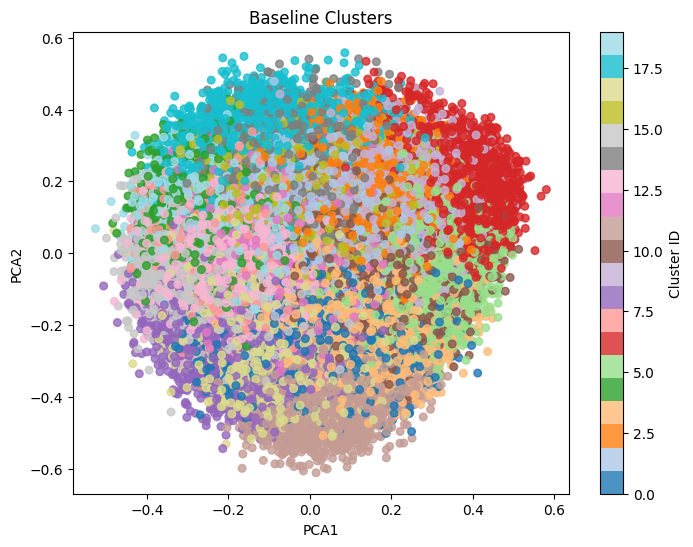

Finished visualization for Baseline Clusters


→ Reducing embeddings for Fine-tuned Clusters
→ Plotting 2D scatter for Fine-tuned Clusters


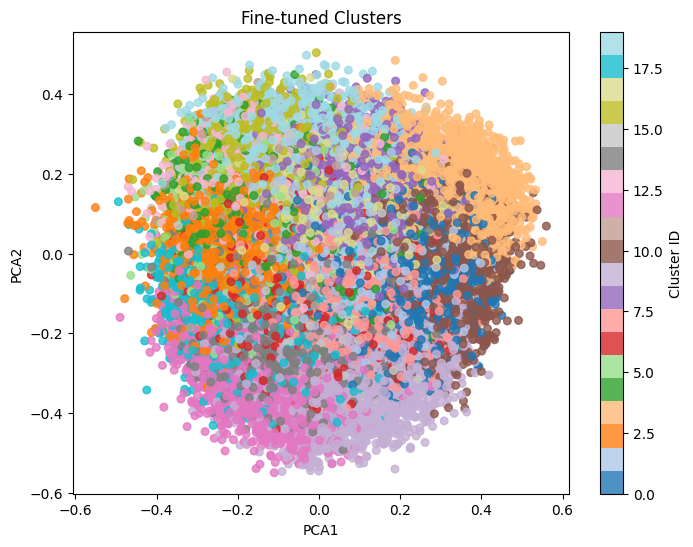

Finished visualization for Fine-tuned Clusters



In [ ]:
import matplotlib.pyplot as plt
# ---------------------------
# Step 9 — Visualization
# ---------------------------
print("=== Step 8: Visualizing PCA Clusters ===")

def plot_pca_clusters_verbose(embeddings, clusters, title):
    print(f"\n→ Reducing embeddings for {title}")
    pca_2d = PCA(n_components=2)
    emb_2d = pca_2d.fit_transform(embeddings)

    print(f"→ Plotting 2D scatter for {title}")
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(emb_2d[:,0], emb_2d[:,1], c=clusters, cmap='tab20', s=30, alpha=0.8)
    plt.title(title)
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.colorbar(scatter, label='Cluster ID')
    plt.show()
    print(f"Finished visualization for {title}\n")

plot_pca_clusters_verbose(baseline_emb_pca, baseline_clusters, "Baseline Clusters")
plot_pca_clusters_verbose(finetuned_emb_pca, finetuned_clusters, "Fine-tuned Clusters")